# Hybrid Recommender
Content-Based (TF-IDF) + Collaborative Filtering (SVD) + Popularity (Bayesian)

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from ml.preprocess import load_data, preprocess_movies_and_tags, build_popularity_scores
from ml.collaborative import CollaborativeRecommender
from ml.content_based import ContentBasedRecommender
from ml.hybrid import HybridRecommender

In [3]:
ratings, movies, tags, links = load_data(
    ratings_path="../data/ratings.csv",
    movies_path="../data/movies.csv",
    tags_path="../data/tags.csv",
    links_path="../data/links.csv"
)

In [4]:
movie_features = preprocess_movies_and_tags(movies, tags, links, include_title=True)
popularity_df = build_popularity_scores(ratings, movie_features)

movie_features.head()

,movieId,title,genres,genres_clean,title_clean,tags,imdbId,tmdbId,content_text
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,adventure animation children comedy fantasy,toy story,pixar pixar fun,114709,862.0,toy story adventure animation children comedy ...
1,2,Jumanji (1995),Adventure|Children|Fantasy,adventure children fantasy,jumanji,fantasy magic board game robin williams game,113497,8844.0,jumanji adventure children fantasy fantasy mag...
2,3,Grumpier Old Men (1995),Comedy|Romance,comedy romance,grumpier old men,moldy old,113228,15602.0,grumpier old men comedy romance moldy old
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,comedy drama romance,waiting to exhale,,114885,31357.0,waiting to exhale comedy drama romance
4,5,Father of the Bride Part II (1995),Comedy,comedy,father of the bride part ii,pregnancy remake,113041,11862.0,father of the bride part ii comedy pregnancy r...


In [5]:
# Antrenare CollaborativeRecommender (SVD fold-in)
collab_model = CollaborativeRecommender(random_state=42)
collab_model.load_ratings(ratings)
collab_model.build_user_matrix()
print(f"CF SVD antrenat: {collab_model.item_factors.shape}")

CF SVD antrenat: (9724, 50)


In [6]:
# Antrenare ContentBasedRecommender (TF-IDF, use_sbert=False pentru viteza)
content_model = ContentBasedRecommender(max_features=5000, use_sbert=False)
content_model.fit(movie_features)
print("CB TF-IDF antrenat.")

CB TF-IDF antrenat.


In [7]:
# Constructie structuri ajutatoare si instantiere HybridRecommender
pop_map = popularity_df.set_index("movieId")["popularity_score"].to_dict()

movie_by_id = {
    int(row.movieId): {
        "title":   row.title,
        "genres":  row.genres,
        "tmdb_id": int(row.tmdbId) if pd.notna(row.tmdbId) else None,
    }
    for row in movie_features.itertuples()
}

all_movie_ids = list(dict.fromkeys(
    int(mid) for mid in movie_features["movieId"].tolist()
    if int(mid) in content_model.movie_id_to_idx
))

hybrid_model = HybridRecommender(
    content_model=content_model,
    collaborative_model=collab_model,
    pop_map=pop_map,
    movie_by_id=movie_by_id,
    all_movie_ids=all_movie_ids,
    weights=(0.55, 0.25, 0.20),
)
print("Hybrid model initializat.")

Hybrid model initializat.


In [8]:
user_id = 1
user_ratings = {
    int(r.movieId): float(r.rating)
    for r in ratings[ratings["userId"] == user_id].itertuples()
}
signal = {mid: r for mid, r in user_ratings.items() if r >= 3.0}

hybrid_recommendations = hybrid_model.recommend(
    signal=signal,
    user_ratings_dict=user_ratings,
    top_n=10,
)
pd.DataFrame(hybrid_recommendations)

,movie_id,tmdb_id,title,genres,similarity_score,reason
0,5657,12719,Flashback (1990),Action|Adventure|Comedy|Crime|Drama,0.7110,Recomandat pentru că ți-a plăcut: Go (1999)
1,2294,8916,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,0.6641,"Recomandat pentru că ți-a plăcut: Goonies, The..."
2,8633,11884,"Last Starfighter, The (1984)",Action|Adventure|Comedy|Sci-Fi,0.6599,"Recomandat pentru că ți-a plăcut: Rocketeer, T..."
3,4226,77,Memento (2000),Mystery|Thriller,0.4650,"Recomandat pentru că ți-a plăcut: Game, The (1..."
4,1022,11224,Cinderella (1950),Animation|Children|Fantasy|Musical|Romance,0.4418,Recomandat pentru că ți-a plăcut: Pinocchio (1...
5,8008,18283,Brigadoon (1954),Fantasy|Musical|Romance,0.4159,Recomandat pentru că ți-a plăcut: Ladyhawke (1...
6,7156,12698,Fog of War: Eleven Lessons from the Life of Ro...,Documentary|War,0.2854,Recomandat pentru că ți-a plăcut: Apocalypse N...
7,3037,11040,Little Big Man (1970),Western,0.2839,Recomandat pentru că ți-a plăcut: Big Trouble ...
8,166024,367412,Whiplash (2013),(no genres listed),0.1906,Recomandat pentru că ți-a plăcut: Toy Story (1...
9,176601,452830,Black Mirror,(no genres listed),0.1868,Recomandat pentru că ți-a plăcut: Black Cauldr...


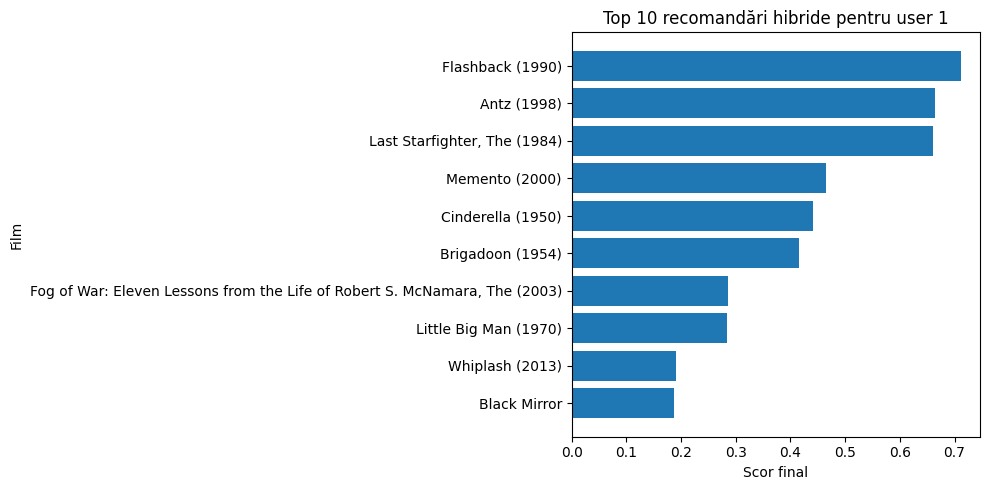

In [9]:
df_hybrid = pd.DataFrame(hybrid_recommendations)
plt.figure(figsize=(10, 5))
plt.barh(df_hybrid["title"], df_hybrid["similarity_score"])
plt.title(f"Top 10 recomandări hibride pentru user {user_id}")
plt.xlabel("Scor final")
plt.ylabel("Film")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../figures/hybrid_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
pd.DataFrame(hybrid_recommendations)[["title", "genres", "similarity_score", "reason"]]

,title,genres,similarity_score,reason
0,Flashback (1990),Action|Adventure|Comedy|Crime|Drama,0.7110,Recomandat pentru că ți-a plăcut: Go (1999)
1,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,0.6641,"Recomandat pentru că ți-a plăcut: Goonies, The..."
2,"Last Starfighter, The (1984)",Action|Adventure|Comedy|Sci-Fi,0.6599,"Recomandat pentru că ți-a plăcut: Rocketeer, T..."
3,Memento (2000),Mystery|Thriller,0.4650,"Recomandat pentru că ți-a plăcut: Game, The (1..."
4,Cinderella (1950),Animation|Children|Fantasy|Musical|Romance,0.4418,Recomandat pentru că ți-a plăcut: Pinocchio (1...
5,Brigadoon (1954),Fantasy|Musical|Romance,0.4159,Recomandat pentru că ți-a plăcut: Ladyhawke (1...
6,Fog of War: Eleven Lessons from the Life of Ro...,Documentary|War,0.2854,Recomandat pentru că ți-a plăcut: Apocalypse N...
7,Little Big Man (1970),Western,0.2839,Recomandat pentru că ți-a plăcut: Big Trouble ...
8,Whiplash (2013),(no genres listed),0.1906,Recomandat pentru că ți-a plăcut: Toy Story (1...
9,Black Mirror,(no genres listed),0.1868,Recomandat pentru că ți-a plăcut: Black Cauldr...


In [11]:
user_id_few_ratings = 2
user_ratings_few = {
    int(r.movieId): float(r.rating)
    for r in ratings[ratings["userId"] == user_id_few_ratings].itertuples()
}
signal_few = {mid: r for mid, r in user_ratings_few.items() if r >= 3.0}

few_ratings_recs = hybrid_model.recommend(
    signal=signal_few,
    user_ratings_dict=user_ratings_few,
    top_n=10,
)
pd.DataFrame(few_ratings_recs)

,movie_id,tmdb_id,title,genres,similarity_score,reason
0,26840,7500,Sonatine (Sonachine) (1993),Action|Comedy|Crime|Drama,0.6730,Recomandat pentru că ți-a plăcut: Collateral (...
1,2419,44326,Extremities (1986),Drama|Thriller,0.5142,Recomandat pentru că ți-a plăcut: Ex Machina (...
2,26712,20562,35 Up (1991),Documentary,0.4000,Recomandat pentru că ți-a plăcut: The Jinx: Th...
3,3727,11879,Near Dark (1987),Horror|Western,0.3319,"Recomandat pentru că ți-a plăcut: Dark Knight,..."
4,115664,228326,The Book of Life (2014),Adventure|Animation|Romance,0.2785,Recomandat pentru că ți-a plăcut: The Jinx: Th...
5,128360,273248,The Hateful Eight (2015),Western,0.2580,Recomandat pentru că ți-a plăcut: Django Uncha...
6,918,909,Meet Me in St. Louis (1944),Musical,0.2332,Recomandat pentru că ți-a plăcut: Louis C.K.: ...
7,7335,25955,Pickup on South Street (1953),Film-Noir,0.2048,Recomandat pentru că ți-a plăcut: Wolf of Wall...
8,913,963,"Maltese Falcon, The (1941)",Film-Noir|Mystery,0.1798,Recomandat pentru că ți-a plăcut: Shutter Isla...
9,60389,14111,Battle for Haditha (2007),War,0.1672,Recomandat pentru că ți-a plăcut: Inglourious ...


In [12]:
# Cold start: semnal artificial pentru un utilizator nou
# Shawshank Redemption, Forrest Gump, Pulp Fiction
cold_signal = {318: 5.0, 356: 4.5, 296: 4.0}

cold_start_recs = hybrid_model.recommend(
    signal=cold_signal,
    user_ratings_dict=cold_signal,
    top_n=10,
)
pd.DataFrame(cold_start_recs)

,movie_id,tmdb_id,title,genres,similarity_score,reason
0,3147,497,"Green Mile, The (1999)",Crime|Drama,0.6980,Recomandat pentru că ți-a plăcut: Shawshank Re...
1,2517,8769,Christine (1983),Horror,0.6163,Recomandat pentru că ți-a plăcut: Shawshank Re...
2,103366,136418,Redemption (Hummingbird) (2013),Action|Crime|Thriller,0.6014,Recomandat pentru că ți-a plăcut: Shawshank Re...
3,2787,10552,Cat's Eye (1985),Horror,0.4347,Recomandat pentru că ți-a plăcut: Shawshank Re...
4,54881,13958,"King of Kong, The (2007)",Documentary,0.3500,Recomandat pentru că ți-a plăcut: Shawshank Re...
5,168252,263115,Logan (2017),Action|Sci-Fi,0.3415,Recomandat pentru că ți-a plăcut: Forrest Gump...
6,139747,283350,Before We Go (2014),Romance,0.1964,Recomandat pentru că ți-a plăcut: Forrest Gump...
7,60389,14111,Battle for Haditha (2007),War,0.1943,Recomandat pentru că ți-a plăcut: Forrest Gump...
8,913,963,"Maltese Falcon, The (1941)",Film-Noir|Mystery,0.1888,Recomandat pentru că ți-a plăcut: Pulp Fiction...
9,3074,11943,Jeremiah Johnson (1972),Western,0.1837,Recomandat pentru că ți-a plăcut: Shawshank Re...


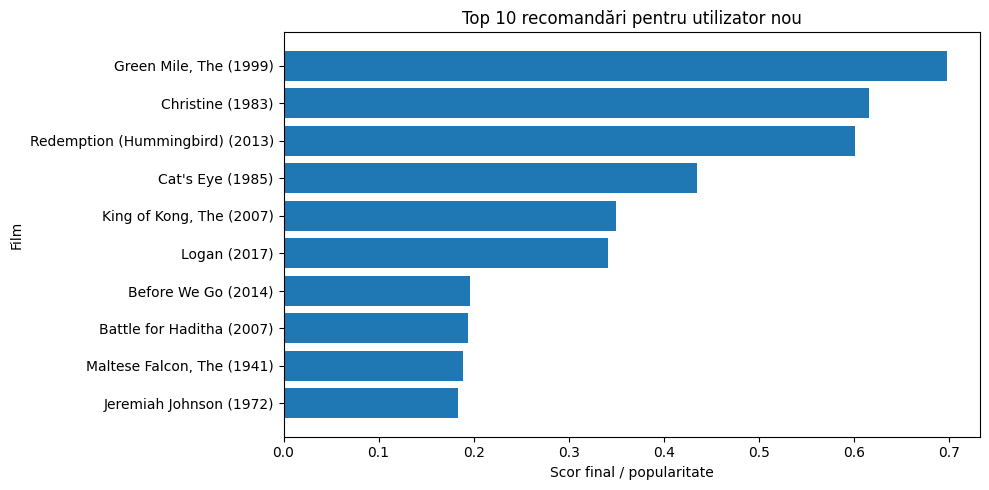

In [13]:
df_cold = pd.DataFrame(cold_start_recs)
plt.figure(figsize=(10, 5))
plt.barh(df_cold["title"], df_cold["similarity_score"])
plt.title("Top 10 recomandări pentru utilizator nou")
plt.xlabel("Scor final / popularitate")
plt.ylabel("Film")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../figures/hybrid_cold_start.png', dpi=150, bbox_inches='tight')
plt.show()